In [112]:
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin

class OutlierClipper(BaseEstimator, TransformerMixin):
    def __init__(self, lower=0.01, upper=0.99):
        self.lower = lower
        self.upper = upper

    def fit(self, X, y=None):
        self.lower_bounds_ = np.quantile(X, self.lower, axis=0)
        self.upper_bounds_ = np.quantile(X, self.upper, axis=0)
        return self

    def transform(self, X):
        return np.clip(X, self.lower_bounds_, self.upper_bounds_)


class RareCategoryGrouper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.01):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.category_maps_ = []
        for col in range(X.shape[1]):
            freqs = pd.Series(X[:, col]).value_counts(normalize=True)
            rare_cats = freqs[freqs < self.threshold].index
            self.category_maps_.append(set(rare_cats))
        return self

    def transform(self, X):
        X_copy = X.copy()
        for col in range(X.shape[1]):
            rare_cats = self.category_maps_[col]
            X_copy[:, col] = [
                "Rare" if val in rare_cats else val
                for val in X_copy[:, col]
            ]
        return X_copy


In [113]:
class TargetDetector:
    def detect(self, df):
        scores = {}
        n_rows = len(df)

        for col in df.columns:
            series = df[col]
            unique_ratio = series.nunique() / n_rows
            score = 0

            if unique_ratio > 0.95:
                score -= 2  # Likely ID

            if series.nunique() < 10:
                score += 2  # Likely classification target

            if pd.api.types.is_numeric_dtype(series):
                score += 1  # Numeric reward

            if series.dtype == "object" and series.nunique() > 50:
                score -= 1  # Text-heavy penalty

            if col.lower() in ["target", "label", "class", "churn", "y"]:
                score += 3

            scores[col] = score

        best_target = max(scores, key=scores.get)
        return best_target


In [114]:
def auto_preprocess_dataset(
    df,
    target_override=None,
    save_path="processed_data.csv"
):

    df = df.copy()

    # -------------------------
    # 1️⃣ Detect Target Column
    # -------------------------
    if target_override:
        target_col = target_override
    else:
        detector = TargetDetector()
        target_col = detector.detect(df)

    print(f"🎯 Target Column → {target_col}")

    # -------------------------
    # 2️⃣ Split Features / Target
    # -------------------------
    X = df.drop(columns=[target_col])
    y = df[target_col]

    # -------------------------
    # 3️⃣ Detect Column Types
    # -------------------------
    numeric_features = X.select_dtypes(include=["int64", "float64"]).columns
    categorical_features = X.select_dtypes(include=["object", "category"]).columns

    print(f"🔢 Numeric Features → {len(numeric_features)}")
    print(f"🔤 Categorical Features → {len(categorical_features)}")

    # -------------------------
    # 4️⃣ Numeric Pipeline
    # -------------------------
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("clipper", OutlierClipper()),
        ("power", PowerTransformer(method="yeo-johnson")),
        ("scaler", StandardScaler())
    ])

    # -------------------------
    # 5️⃣ Categorical Pipeline
    # -------------------------
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("rare", RareCategoryGrouper()),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first",          # ✅ FIXED HERE
            sparse_output=False
        ))
    ])

    # -------------------------
    # 6️⃣ Column Transformer
    # -------------------------
    preprocessor = ColumnTransformer([
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ])

    # -------------------------
    # 7️⃣ Fit & Transform
    # -------------------------
    X_processed = preprocessor.fit_transform(X)

    # -------------------------
    # 8️⃣ Recover Feature Names
    # -------------------------
    cat_feature_names = preprocessor.named_transformers_["cat"] \
        .named_steps["encoder"] \
        .get_feature_names_out(categorical_features)

    all_features = list(numeric_features) + list(cat_feature_names)

    processed_df = pd.DataFrame(X_processed, columns=all_features)

    # Reattach target
    processed_df[target_col] = y.values

    # -------------------------
    # 9️⃣ Save Dataset
    # -------------------------
    processed_df.to_csv(save_path, index=False)

    print(f"💾 Processed dataset saved → {save_path}")
    print("✅ Preprocessing Complete")

    return processed_df


In [115]:
df = pd.read_csv("data.csv")

In [116]:
processed_df = auto_preprocess_dataset(df)


🎯 Target Column → Churn
🔢 Numeric Features → 3
🔤 Categorical Features → 17
💾 Processed dataset saved → processed_data.csv
✅ Preprocessing Complete


In [117]:

X = processed_df.drop(columns=["Churn"])
y = processed_df["Churn"]


In [118]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)   # Yes/No → 1/0


In [119]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)


In [120]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
LogisticRegression(class_weight="balanced")



LogisticRegression(class_weight='balanced')

In [121]:
y_pred = model.predict(X_test)


In [122]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("✅ Accuracy:", accuracy)


✅ Accuracy: 0.8034066713981547


In [123]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Confusion Matrix:
 [[934 101]
 [176 198]]


In [124]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



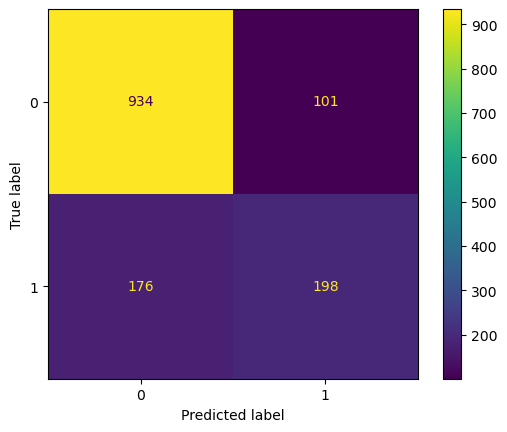

In [125]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()


In [126]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=10,
    class_weight="balanced",
    random_state=42
)


rf.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=8,
                       min_samples_leaf=10, n_estimators=300, random_state=42)

In [127]:
y_probs = rf.predict_proba(X_test)[:, 1]
y_pred_adj = (y_probs > 0.35).astype(int)



In [128]:
from sklearn.metrics import accuracy_score

print("✅ Accuracy:", accuracy_score(y_test, y_pred_rf))


✅ Accuracy: 0.7856635911994322


              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

